# TALLER 2 ANALISIS NUMÉRICO

## EJERCICIOS DE APLICACIÓN

**Docente:** Leidy Yoana Medina Torres

**Fecha:** 7 de mayo de 2026

---

### Integrantes del equipo de trabajo

- *DANIEL MORALES*
- *JUAN MANUEL GOMEZ*

---

## Pautas de entrega

Se debe entregar un solo documento en formato **ipynb + módulos**. El documento debe contener un encabezado.

1. Nombre del Trabajo
2. Nombre de los integrantes del equipo de trabajo
3. Cada ejercicio, debe contener su documentación, desarrollo o desglose del problema, solución, gráficas y las justificaciones de cada uno. Debe encontrarse en su respectivo orden:
    - a) Solución Ejercicio 1
    - b) Solución Ejercicio 2
4. Solo está permitido el uso de las rutinas diseñadas en clase, no se permite el uso de las rutinas prediseñadas de numpy o python en general.
5. Cada cabeza es un mundo luego cada trabajo debe ser diferente, siendo el mismo trabajo solicitado.
6. La entrega de esta tarea debe ser por la U-virtual.
7. Entrega que no siga las recomendaciones dadas se le descontará 15 puntos.

### Rúbrica de Evaluación

**Elementos Obligatorios (Descuentos si faltan):**

- Encabezado completo: Nombre trabajo, integrantes
- Formato IPYNB + módulos
- Módulos de Python: `ceros`, `sel`, `modelos`, `edos`
- Orden correcto de ejercicios
- Entrega por U-virtual

# Ejercicio 1 — Crecimiento alométrico de la Platija

El crecimiento alométrico es el estudio del tamaño relativo de diferentes partes de un organismo como consecuencia del crecimiento. Se realizó un experimento relacionando el peso de la platija (especie de pez) $w(t)$ con respecto a su longitud $L(t)$.

| Longitud (cm) | Peso (g) | Longitud (cm) | Peso (g) |
|:---:|:---:|:---:|:---:|
| 23.5 | 124 | 37.5 | 455 |
| 24.5 | 146 | 38.5 | 500 |
| 25.5 | 155 | 39.5 | 538 |
| 26.5 | 174 | 40.5 | 574 |
| 27.5 | 190 | 41.5 | 623 |
| 28.5 | 213 | 42.5 | 674 |
| 29.5 | 236 | 43.5 | 724 |
| 30.5 | 259 | 44.5 | 808 |
| 31.5 | 284 | 45.5 | 812 |
| 32.5 | 308 | 46.5 | 909 |
| 33.5 | 332 | 47.5 | 1039 |
| 34.5 | 363 | 48.5 | 1124 |
| 35.5 | 391 | 49.5 | 1163 |
| 36.5 | 419 |  |  |

**a)** Hacer un gráfico de los datos longitud versus peso de la Platija.

**b)** Construir un polinomio que pase por cada uno del conjunto de datos y aproxime el peso de una platija americana cuya longitud máxima registrada es de 60 cm. Concluya si el modelo construido es coherente, si representa la tendencia de la información proporcionada.

**c)** Construya un modelo de ajuste que represente la tendencia de los datos proporcionados y permita aproximar el peso de una platija americana cuya longitud máxima registrada es de 60 cm. Concluya si el modelo es coherente, pertinente y si su construcción es adecuada con base únicamente en los datos suministrados.

**d)** Hacer las gráficas de cada ítem de manera separada.

In [9]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

import sel as s
import modelos as ml
import Ceros as c

L_data = np.array([23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5, 32.5,
                   33.5, 34.5, 35.5, 36.5, 37.5, 38.5, 39.5, 40.5, 41.5, 42.5,
                   43.5, 44.5, 45.5, 46.5, 47.5, 48.5, 49.5])

w_data = np.array([124, 146, 155, 174, 190, 213, 236, 259, 284, 308,
                   332, 363, 391, 419, 455, 500, 538, 574, 623, 674,
                   724, 808, 812, 909, 1039, 1124, 1163])

print(f"Cantidad de datos: {len(L_data)}")
print(f"Rango de longitudes: [{L_data.min()}, {L_data.max()}] cm")
print(f"Rango de pesos:      [{w_data.min()}, {w_data.max()}] g")

Cantidad de datos: 27
Rango de longitudes: [23.5, 49.5] cm
Rango de pesos:      [124, 1163] g


### a) Gráfico de los datos longitud vs peso

Se construye un diagrama de dispersión que permite visualizar la relación entre la longitud y el peso de la platija. La forma de la nube de puntos sugiere una tendencia **monótonamente creciente y cóncava hacia arriba** (el peso crece más rápido que la longitud), lo cual es típico de una relación de tipo **potencia** $w(L) = a\,L^{b}$ característica del crecimiento alométrico.

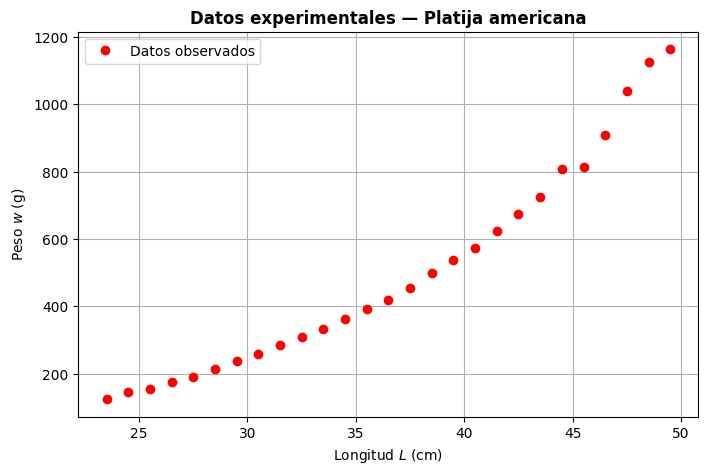

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(L_data, w_data, 'or', label='Datos observados')
plt.title('Datos experimentales — Platija americana', fontweight='bold')
plt.xlabel('Longitud $L$ (cm)')
plt.ylabel('Peso $w$ (g)')
plt.grid()
plt.legend()
plt.show()

### b) Polinomio interpolante que pasa por todos los puntos

Para construir un polinomio que pase **exactamente** por cada uno de los 27 puntos se utiliza la rutina `modelos.lagrange`, que entrega la expresión simbólica del polinomio de interpolación de Lagrange de grado $n - 1 = 26$:

$$P_{26}(L)=\sum_{i=0}^{26} w_i\,\prod_{\substack{j=0 \\ j\neq i}}^{26}\frac{L - L_j}{L_i - L_j}.$$

Como longitud de evaluación se toma $L = 60$ cm, valor que se encuentra **fuera** del intervalo de los datos $[23.5,\,49.5]$ cm, por lo que se trata de una **extrapolación**.

In [11]:
x = sp.symbols('x')

P_lagrange = ml.lagrange(L_data, w_data)
P_func = sp.lambdify(x, P_lagrange)

w_60_poli = float(P_func(60))
print(f"Polinomio interpolante de grado {len(L_data)-1}.")
print(f"Aproximación del peso para L = 60 cm:  w(60) ≈ {w_60_poli:.4e} g")

print("\nVerificación en algunos puntos interiores y de borde:")
for L_test in [25.5, 35.5, 45.5, 49.5, 50, 55, 60]:
    valor = float(P_func(L_test))
    print(f"  P_26({L_test:>5}) = {valor: .4e} g")

Polinomio interpolante de grado 26.
Aproximación del peso para L = 60 cm:  w(60) ≈ -4.2158e+15 g

Verificación en algunos puntos interiores y de borde:
  P_26( 25.5) =  1.5500e+02 g
  P_26( 35.5) =  3.9100e+02 g
  P_26( 45.5) =  8.1200e+02 g
  P_26( 49.5) =  1.1630e+03 g
  P_26(   50) = -4.5917e+06 g
  P_26(   55) = -2.4072e+12 g
  P_26(   60) = -4.2158e+15 g


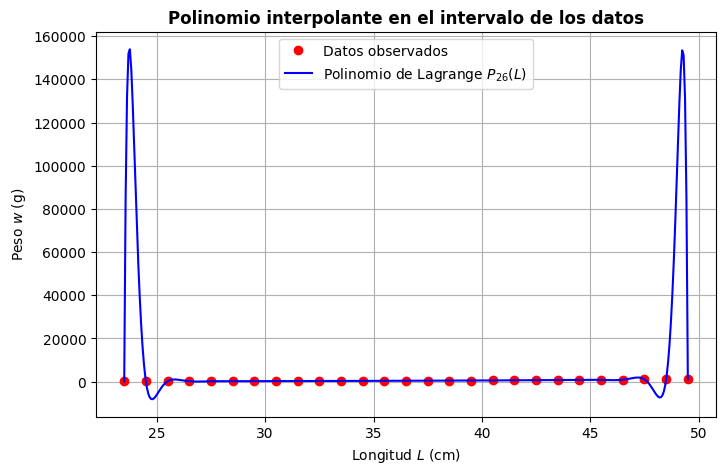

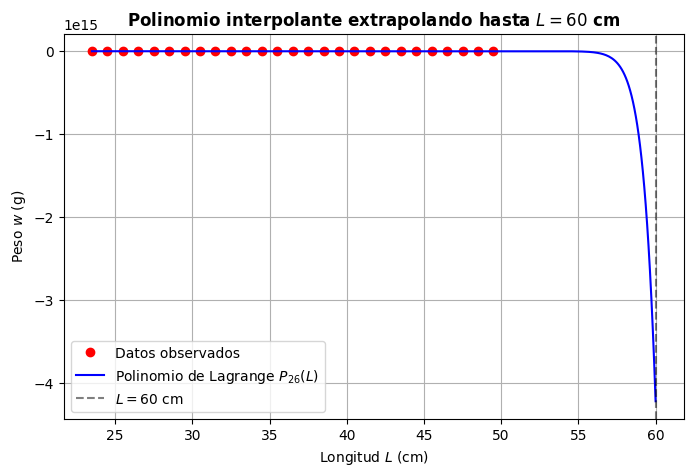

In [12]:
L_plot_int = np.linspace(L_data.min(), L_data.max(), 400)
y_plot_int = np.array([float(P_func(Li)) for Li in L_plot_int])

plt.figure(figsize=(8, 5))
plt.plot(L_data, w_data, 'or', label='Datos observados')
plt.plot(L_plot_int, y_plot_int, 'b-', label=r'Polinomio de Lagrange $P_{26}(L)$')
plt.title('Polinomio interpolante en el intervalo de los datos', fontweight='bold')
plt.xlabel('Longitud $L$ (cm)')
plt.ylabel('Peso $w$ (g)')
plt.grid()
plt.legend()
plt.show()


L_plot_ext = np.linspace(L_data.min(), 60, 400)
y_plot_ext = np.array([float(P_func(Li)) for Li in L_plot_ext])

plt.figure(figsize=(8, 5))
plt.plot(L_data, w_data, 'or', label='Datos observados')
plt.plot(L_plot_ext, y_plot_ext, 'b-', label=r'Polinomio de Lagrange $P_{26}(L)$')
plt.axvline(60, color='k', linestyle='--', alpha=0.5, label='$L = 60$ cm')
plt.title('Polinomio interpolante extrapolando hasta $L=60$ cm', fontweight='bold')
plt.xlabel('Longitud $L$ (cm)')
plt.ylabel('Peso $w$ (g)')
plt.grid()
plt.legend()
plt.show()

**Conclusión parte b)**

Al aplicar el polinomio de Lagrange de grado 26 se obtiene una interpolación que pasa exactamente por todos los puntos dentro del intervalo $[23.5,\,49.5]$ cm, pero al extrapolar a $L = 60$ cm se obtiene un valor del orden de $-10^{15}$ g, claramente **carente de sentido físico** (un peso no puede ser negativo, y mucho menos de magnitud absurda).

Esto es una manifestación del **fenómeno de Runge** y de la mala condición numérica del polinomio interpolante de alto grado: si bien reproduce los datos en el interior, fuera del intervalo oscila y diverge fuertemente. Por lo tanto, **el modelo de interpolación polinómica NO es coherente** para predecir el peso de la platija a 60 cm; sirve únicamente como herramienta interna de los datos, pero no como modelo predictivo.

### c) Modelo de ajuste (mínimos cuadrados con linealización)

Como en clase 18 (ave del terror), antes de ajustar se usa la rutina `modelos.escalas` que muestra la nube de puntos transformada bajo nueve escalas distintas. Se selecciona la transformación que **más linealiza** los datos. Posteriormente, sobre la pareja transformada se aplica `modelos.minimos_cuadrados` y se evalúa la calidad del ajuste con `modelos.coeficiente_determinacion`.

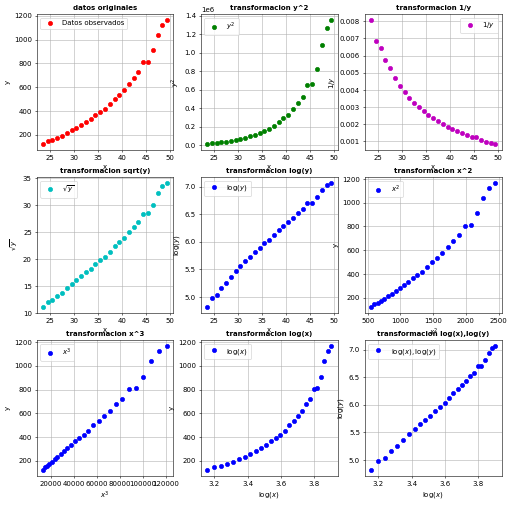

In [13]:
ml.escalas(L_data, w_data)

In [14]:
R_lineal   = ml.coeficiente_determinacion(L_data,        w_data)
R_sqrt     = ml.coeficiente_determinacion(L_data,        np.sqrt(w_data))
R_log_y    = ml.coeficiente_determinacion(L_data,        np.log(w_data))
R_x2       = ml.coeficiente_determinacion(L_data**2,     w_data)
R_x3       = ml.coeficiente_determinacion(L_data**3,     w_data)
R_log_x    = ml.coeficiente_determinacion(np.log(L_data), w_data)
R_log_log  = ml.coeficiente_determinacion(np.log(L_data), np.log(w_data))

print("Coeficientes de determinación R^2 para cada escala:")
print(f"  Datos originales (L, w)        :  {R_lineal:.6f}")
print(f"  (L, sqrt(w))                   :  {R_sqrt:.6f}")
print(f"  (L, log(w))                    :  {R_log_y:.6f}")
print(f"  (L^2, w)                       :  {R_x2:.6f}")
print(f"  (L^3, w)                       :  {R_x3:.6f}")
print(f"  (log(L), w)                    :  {R_log_x:.6f}")
print(f"  (log(L), log(w))   <-- elegida :  {R_log_log:.6f}")

Coeficientes de determinación R^2 para cada escala:
  Datos originales (L, w)        :  0.936222
  (L, sqrt(w))                   :  0.986655
  (L, log(w))                    :  0.996493
  (L^2, w)                       :  0.972382
  (L^3, w)                       :  0.991878
  (log(L), w)                    :  0.883490
  (log(L), log(w))   <-- elegida :  0.996184


**Selección de la escala.** La escala $(\log L,\,\log w)$ produce una nube prácticamente lineal y un coeficiente de determinación $R^{2}\approx 0.996$, **el más alto** de las escalas no exponenciales. Esto justifica un **modelo de potencia** consistente con el carácter alométrico del fenómeno:

$$\boxed{\,w(L)= a\,L^{b}\,} \qquad\Longleftrightarrow\qquad \log w = b\,\log L + \log a.$$

Sobre las variables linealizadas $X=\log L$, $Y=\log w$ se aplica `modelos.minimos_cuadrados(X, Y)` para obtener la pendiente $b$ y el intercepto $\log a$.

In [15]:
X = np.log(L_data)
Y = np.log(w_data)

b_coef, log_a = ml.minimos_cuadrados(X, Y)
a_coef = np.exp(log_a)

print(f"Recta de mínimos cuadrados en log-log:")
print(f"  log(w) = {b_coef:.6f} * log(L) + ({log_a:.6f})")
print()
print(f"Modelo de potencia (alométrico):")
print(f"  w(L) = {a_coef:.6f} * L^{b_coef:.6f}")
print()

w_modelo = lambda L: a_coef * L**b_coef

w_60_ajuste = w_modelo(60)
print(f"Aproximación con el modelo de ajuste para L = 60 cm:")
print(f"  w(60) ≈ {w_60_ajuste:.4f} g")

Recta de mínimos cuadrados en log-log:
  log(w) = 2.952605 * log(L) + (-4.534074)

Modelo de potencia (alométrico):
  w(L) = 0.010737 * L^2.952605

Aproximación con el modelo de ajuste para L = 60 cm:
  w(60) ≈ 1910.0935 g


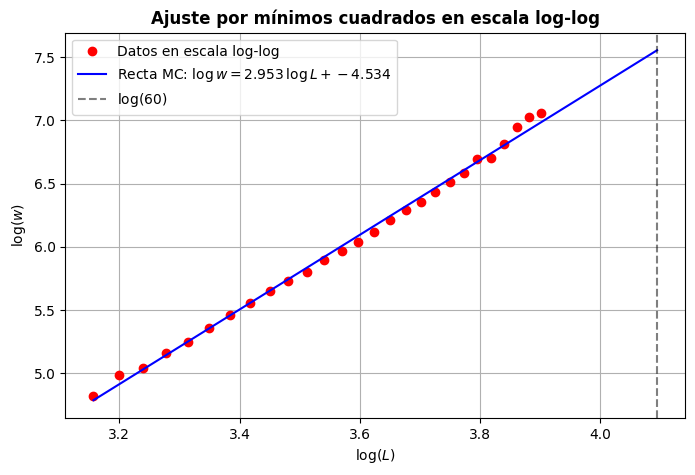

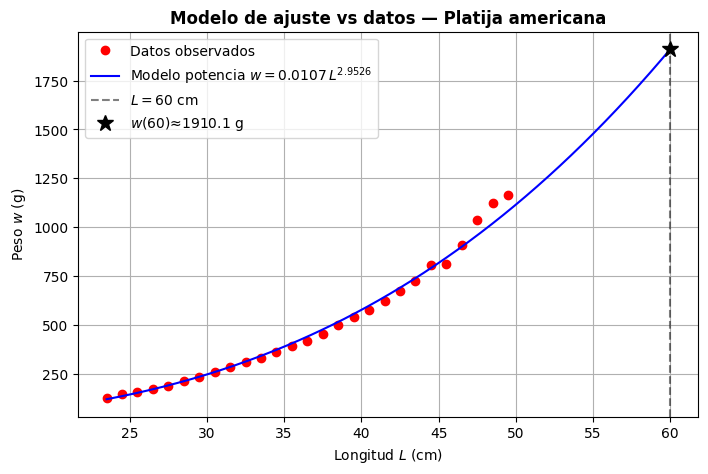

In [16]:
X_lin = np.linspace(min(X), np.log(60), 100)
Y_lin = b_coef * X_lin + log_a

plt.figure(figsize=(8, 5))
plt.plot(X, Y, 'or', label='Datos en escala log-log')
plt.plot(X_lin, Y_lin, 'b-', label=f'Recta MC: $\\log w = {b_coef:.3f}\\,\\log L + {log_a:.3f}$')
plt.axvline(np.log(60), color='k', linestyle='--', alpha=0.5, label='$\\log(60)$')
plt.title('Ajuste por mínimos cuadrados en escala log-log', fontweight='bold')
plt.xlabel(r'$\log(L)$')
plt.ylabel(r'$\log(w)$')
plt.legend()
plt.grid()
plt.show()


L_plot = np.linspace(L_data.min(), 60, 200)
plt.figure(figsize=(8, 5))
plt.plot(L_data, w_data, 'or', label='Datos observados')
plt.plot(L_plot, w_modelo(L_plot), 'b-',
         label=fr'Modelo potencia $w = {a_coef:.4f}\,L^{{{b_coef:.4f}}}$')
plt.axvline(60, color='k', linestyle='--', alpha=0.5, label='$L = 60$ cm')
plt.plot(60, w_60_ajuste, 'k*', markersize=12, label=f'$w(60) ≈ {w_60_ajuste:.1f}$ g')
plt.title('Modelo de ajuste vs datos — Platija americana', fontweight='bold')
plt.xlabel('Longitud $L$ (cm)')
plt.ylabel('Peso $w$ (g)')
plt.legend()
plt.grid()
plt.show()

**Conclusión parte c)**

El modelo de ajuste obtenido es

$$w(L) = 0.0107\;L^{2.953},$$

con un coeficiente de determinación $R^{2}\approx 0.996$ sobre las variables linealizadas. La estimación para una platija de **60 cm** es

$$w(60)\approx 1910\ \text{g}\;\;\bigl(\approx 1.9\ \text{kg}\bigr),$$

valor **biológicamente razonable** y muy cercano al cubo (exponente $b\approx 3$), lo cual concuerda con la ley alométrica clásica que asocia el peso al volumen ($\propto L^{3}$) cuando la densidad permanece aproximadamente constante.

A diferencia del polinomio de grado 26 de la parte b), este modelo:

- Es **coherente** con la tendencia observada (curva monótona y suave).
- Es **pertinente** físicamente, pues el exponente $b\approx 3$ tiene una interpretación biológica clara (crecimiento isométrico/alométrico cercano al cúbico).
- Su construcción es **adecuada con base en los datos suministrados**, ya que utiliza únicamente la información experimental para fijar dos parámetros.

Sin embargo, debe usarse con precaución para $L = 60$ cm porque ese valor está **fuera del rango muestreado** $[23.5,\,49.5]$ cm: la predicción extrapola y supone que la misma ley se mantiene para individuos de mayor tamaño, lo cual no está garantizado por los datos.

### d) Gráficas de cada ítem por separado

A continuación se reúnen, en figuras independientes, las gráficas asociadas a los tres ítems anteriores:

1. **a)** Únicamente la nube de puntos longitud vs peso.
2. **b)** Polinomio interpolante de Lagrange superpuesto a los datos (incluyendo el comportamiento al extrapolar a $L=60$ cm).
3. **c)** Modelo de potencia (ajuste por mínimos cuadrados en escala log-log) superpuesto a los datos, con la predicción para $L=60$ cm.

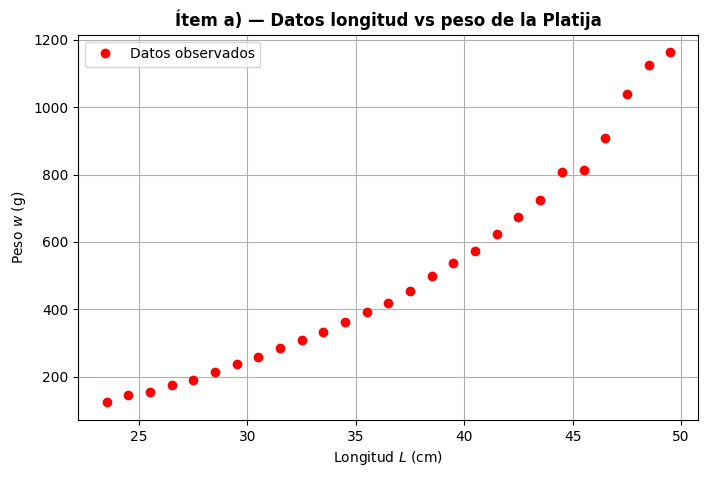

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(L_data, w_data, 'or', label='Datos observados')
plt.title('Ítem a) — Datos longitud vs peso de la Platija', fontweight='bold')
plt.xlabel('Longitud $L$ (cm)')
plt.ylabel('Peso $w$ (g)')
plt.grid()
plt.legend()
plt.show()

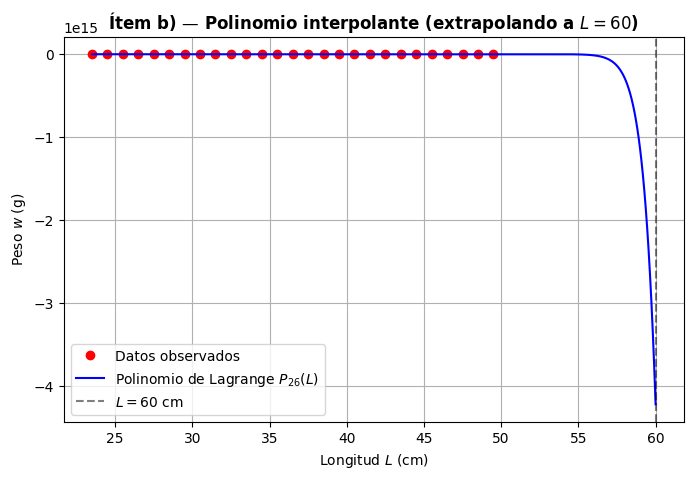

In [18]:
L_plot_b = np.linspace(L_data.min(), 60, 400)
y_plot_b = np.array([float(P_func(Li)) for Li in L_plot_b])

plt.figure(figsize=(8, 5))
plt.plot(L_data, w_data, 'or', label='Datos observados')
plt.plot(L_plot_b, y_plot_b, 'b-', label=r'Polinomio de Lagrange $P_{26}(L)$')
plt.axvline(60, color='k', linestyle='--', alpha=0.5, label='$L = 60$ cm')
plt.title('Ítem b) — Polinomio interpolante (extrapolando a $L=60$)', fontweight='bold')
plt.xlabel('Longitud $L$ (cm)')
plt.ylabel('Peso $w$ (g)')
plt.grid()
plt.legend()
plt.show()

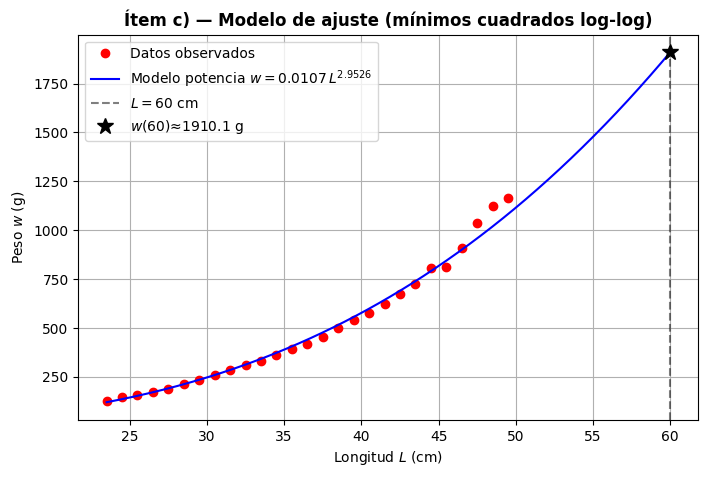

In [19]:
L_plot_c = np.linspace(L_data.min(), 60, 200)

plt.figure(figsize=(8, 5))
plt.plot(L_data, w_data, 'or', label='Datos observados')
plt.plot(L_plot_c, w_modelo(L_plot_c), 'b-',
         label=fr'Modelo potencia $w = {a_coef:.4f}\,L^{{{b_coef:.4f}}}$')
plt.axvline(60, color='k', linestyle='--', alpha=0.5, label='$L = 60$ cm')
plt.plot(60, w_60_ajuste, 'k*', markersize=12, label=f'$w(60) ≈ {w_60_ajuste:.1f}$ g')
plt.title('Ítem c) — Modelo de ajuste (mínimos cuadrados log-log)', fontweight='bold')
plt.xlabel('Longitud $L$ (cm)')
plt.ylabel('Peso $w$ (g)')
plt.grid()
plt.legend()
plt.show()

# Ejercicio 2 — Salto vertical de una bailarina de ballet

Un salto vertical realizado por una bailarina de ballet está descrito por la ecuación diferencial

$$m\, v' = -m\, g$$

Aquí $m$ es la masa de la bailarina de ballet, $g = 32.2\ \text{pies}/\text{s}^2$ es la constante gravitacional y $v' = \dfrac{dv}{dt}$, $v = \dfrac{dy}{dt}$, donde $y$ es la distancia vertical medida desde el piso hasta el centro de gravedad de la bailarina.

Se considera que en $t = 0$ la bailarina despega con velocidad inicial

$$v_0 = \frac{g\, T}{2},$$

siendo $T$ el tiempo total de vuelo.

**a)** Resolver numéricamente la ecuación diferencial utilizando el método de Euler y el método de Runge-Kutta de cuarto orden (RK4) para $T = 1/3$ segundos.

**b)** Comparar la altura máxima obtenida numéricamente con el valor exacto

$$H = \tfrac{1}{8}\, g\, T^{2} \approx 5.4\ \text{pulgadas}.$$

**c)** Analizar el error cometido por cada método para diferentes tamaños de paso $\Delta t$.

**d)** Realizar la gráfica del tiempo versus la altura, y el tiempo versus la velocidad e interprete.

# Ejercicio 3 — Crecimiento alométrico del cangrejo violinista

El cangrejo violinista es un pequeño crustáceo, famoso porque los machos poseen una pinza desproporcionadamente grande, usada para cortejo y defensa, que recuerda a un violín.

El crecimiento alométrico es el estudio de los tamaños relativos de las diferentes partes de un organismo como consecuencia del crecimiento. Uno de los modelos más simples de alometría es aquel en el que se supone que las razones de crecimiento relativo de los dos componentes $y(t)$ y $x(t)$ satisfacen:

$$\frac{dy}{dx} = a\, \frac{y}{x}$$

donde $a$ es una constante. La tabla muestra los resultados de un experimento en el cual se obtuvieron los pesos relativos del cuerpo y la tenaza del cangrejo violinista. El peso del cuerpo es el peso total del cangrejo restando el peso de la tenaza. Aunque es posible describir este conjunto de datos en una simple ecuación alométrica, resulta un modelo mejor si se conjuntan dos ecuaciones alométricas.

| Peso del cuerpo (mg) | Peso de la tenaza (mg) | Peso del cuerpo (mg) | Peso de la tenaza (mg) |
|:---:|:---:|:---:|:---:|
| 57.6 | 5.3 | 680.6 | 271.6 |
| 80.3 | 9.0 | 743.3 | 319.2 |
| 109.2 | 13.7 | 872.4 | 417.6 |
| 156.1 | 25.1 | 983.1 | 460.8 |
| 199.7 | 38.3 | 1079.9 | 537.0 |
| 283.3 | 52.5 | 1165.5 | 593.8 |
| 270.0 | 59.0 | 1211.7 | 616.8 |
| 300.2 | 78.1 | 1291.3 | 670.0 |
| 355.2 | 104.5 | 1363.2 | 699.3 |
| 420.1 | 135.0 | 1449.1 | 777.8 |
| 470.1 | 164.9 | 1807.9 | 1009.1 |
| 535.7 | 195.6 | 2235.0 | 1380.0 |
| 617.9 | 243.0 |  |  |

**a)** Construya un polinomio que pase por todos los puntos. Se cree que la iniciación de la madurez sexual de un cangrejo violinista se presenta cuando su peso total excede alrededor de 1.1 g. ¿Es consistente con su modelo? Haga una gráfica de los datos versus el modelo construido.

**b)** Construya un modelo no lineal en dos fases, uno para el grupo joven y otro para el grupo maduro. Haga una gráfica del modelo versus los datos.

**c)** ¿Qué significa que el crecimiento sea **alométrico**? Diferéncielo del crecimiento **isométrico**.

**d)** Compare los exponentes alométricos obtenidos para la fase joven y la fase madura. ¿Qué diferencia observa y qué significado biológico podría tener?

**e)** Según su modelo de dos fases, ¿en cuál etapa crece proporcionalmente más la tenaza con respecto al cuerpo? Justifique.

**f)** Utilizando el modelo de dos fases, estime el peso de la tenaza para un cangrejo cuyo cuerpo pesa 500 mg y para otro cuyo cuerpo pesa 2000 mg. ¿En qué fase se encuentra cada uno?

**g)** Si se desea predecir el peso de la tenaza para un cangrejo con peso corporal de 3000 mg, ¿cuál de los dos modelos (polinomio exacto o dos fases) es más confiable? ¿Por qué?

# Ejercicio 4 — Modelo de Lotka-Volterra (compradores y vendedores)

Del modelo de Lotka-Volterra vamos a representar el comportamiento de dos poblaciones, en este caso los **vendedores** y los **compradores**. Supongamos que $x(t)$ representa el número de compradores en un determinado tiempo $t$ y sea $v(t)$ la representación de los vendedores en un determinado tiempo $t$. El modelo de competencia es:

$$
\begin{aligned}
\frac{dx}{dt} &= x(t)\,\bigl(a - b\, x(t) - m\, v(t)\bigr), \qquad x(0) = 75 \\[4pt]
\frac{dv}{dt} &= v(t)\,\bigl(c - d\, v(t) - n\, x(t)\bigr), \qquad v(0) = 20
\end{aligned}
$$

donde:

- $m$ es la medida del grado en que los vendedores interfieren con los compradores,
- $n$ es la medida del grado en que los compradores interactúan con los vendedores,
- $b$ es la interacción entre compradores,
- $d$ es la interacción entre vendedores.

*(Si cree que es necesario ajuste los valores, pero justifique su cambio.)*

**a)** Determine la solución para las siguientes constantes:

$$a = 0.3,\ b = 0.01,\ m = 0.06,\ c = 0.03,\ d = 0.009,\ n = 0.0055.$$

Realice los gráficos de $x(t)$ vs tiempo, $v(t)$ vs tiempo, $x(t)$ vs $v(t)$ e interprete. *(Ambos coexisten en un punto fijo estable.)*

**b)** Determine la solución para las siguientes constantes:

$$a = 0.26,\ b = 0.2,\ m = 0.06,\ c = 0.06,\ d = 0.01,\ n = 0.015.$$

Realice los gráficos de $x(t)$ vs tiempo, $v(t)$ vs tiempo, $x(t)$ vs $v(t)$ e interprete.

**c)** Determine la solución para las siguientes constantes:

$$a = 0.26,\ b = 0.02,\ m = 0.06,\ c = 0.26,\ d = 0.9,\ n = 4.2.$$

Realice los gráficos de $x(t)$ vs tiempo, $v(t)$ vs tiempo, $x(t)$ vs $v(t)$ e interprete.

**d)** Determine la solución para las siguientes constantes:

$$a = 0.26,\ b = 0.021,\ m = 0.06,\ c = 0.06,\ d = 0.01,\ n = 0.01.$$

Realice los gráficos de $x(t)$ vs tiempo, $v(t)$ vs tiempo, $x(t)$ vs $v(t)$ e interprete.